Exploratory Data Analysis(EDA) is a crucial step in Data Science that involves summarizing and visualizing the important characteristics of a dataset.

This process helps in understanding the data, detecting anomalies and identifying patterns.


### Steps For Exploratory Data Analysis

1.   Loading the Data
2.   Initial data inspection
3.   Summary Statistics
4.   Missing values analysis
5.   Data Cleaning
6.   Data Visualization


This notebook conducts exploratory data analysis (EDA) on a synthetic Fintech SaaS dataset to uncover insights into customer usage, revenue generation, and churn dynamics.




1. LOADING THE DATA

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset in csv format
df = pd.read_csv('/content/fintech_saas_dataset.csv')

# displaying the first five rows of the dataset
df.head()

,customer_id,subscription_tier,monthly_fee,tenure_months,num_transactions,avg_transaction_value,active_users,churned,customer_support_tickets,region,marketing_channel,monthly_revenue
0,1,Enterprise,50.0,2.0,79,26.86,29,0,5,Africa,Organic,1450
1,2,Basic,50.0,50.0,53,174.18,30,0,3,Asia,Referral,1500
2,3,Enterprise,250.0,6.0,338,318.29,10,1,0,Asia,Partnership,2500
3,4,Enterprise,100.0,9.0,310,39.17,39,0,6,Africa,Referral,3900
4,5,Basic,25.0,33.0,237,7.80,28,1,8,Africa,Referral,700


In [22]:
# displaying the last ten rows of the dataset
df.tail(10)

,customer_id,subscription_tier,monthly_fee,tenure_months,num_transactions,avg_transaction_value,active_users,churned,customer_support_tickets,region,marketing_channel,monthly_revenue
990,991,Pro,10.0,14.0,172,NaN,8,0,8,North America,Paid Ads,80
991,992,Enterprise,100.0,56.0,28,222.04,29,0,10,Asia,Organic,2900
992,993,Pro,10.0,10.0,379,267.29,48,0,4,Asia,Partnership,480
993,994,Enterprise,10.0,16.0,273,492.73,33,0,2,Europe,Paid Ads,330
994,995,Pro,50.0,16.0,291,87.18,3,1,16,Asia,Partnership,150
995,996,Pro,250.0,54.0,122,NaN,35,0,1,North America,Organic,8750
996,997,Pro,250.0,31.0,497,9.31,5,0,0,Asia,Referral,1250
997,998,Enterprise,10.0,42.0,336,82.01,27,0,6,Africa,Paid Ads,270
998,999,Enterprise,25.0,25.0,39,107.60,44,1,13,Africa,Paid Ads,1100
999,1000,Basic,100.0,NaN,144,317.14,12,0,4,Europe,Partnership,1200


2. INITIAL DATA INSPECTION

In [23]:
# display the basic structure and summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1000 non-null   int64  
 1   subscription_tier         900 non-null    object 
 2   monthly_fee               900 non-null    float64
 3   tenure_months             900 non-null    float64
 4   num_transactions          1000 non-null   int64  
 5   avg_transaction_value     900 non-null    float64
 6   active_users              1000 non-null   int64  
 7   churned                   1000 non-null   int64  
 8   customer_support_tickets  1000 non-null   int64  
 9   region                    900 non-null    object 
 10  marketing_channel         900 non-null    object 
 11  monthly_revenue           1000 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 93.9+ KB


In [24]:
# display the summary statistics of the dataset
#(include all) displays all the data; both categorical and numerical
df.describe(include='all')

,customer_id,subscription_tier,monthly_fee,tenure_months,num_transactions,avg_transaction_value,active_users,churned,customer_support_tickets,region,marketing_channel,monthly_revenue
count,1000.000000,900,900.000000,900.000000,1000.000000,900.000000,1000.000000,1000.00000,1000.000000,900,900,1000.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN
top,NaN,Basic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Asia,Paid Ads,NaN
freq,NaN,325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237,237,NaN
mean,500.500000,NaN,87.061111,29.136667,259.476000,260.776622,25.067000,0.19300,9.309000,NaN,NaN,2202.315000
std,288.819436,NaN,87.709715,16.880730,141.444795,141.695763,14.047272,0.39485,5.794056,NaN,NaN,2823.458001
min,1.000000,NaN,10.000000,1.000000,10.000000,5.220000,1.000000,0.00000,0.000000,NaN,NaN,10.000000
25%,250.750000,NaN,25.000000,15.000000,136.000000,141.160000,13.000000,0.00000,4.000000,NaN,NaN,370.000000
50%,500.500000,NaN,50.000000,28.500000,266.500000,269.215000,25.000000,0.00000,9.000000,NaN,NaN,1025.000000
75%,750.250000,NaN,100.000000,44.000000,385.000000,381.890000,37.000000,0.00000,15.000000,NaN,NaN,2700.000000


3. SUMMARY STATISTICS

In [25]:
# summary statistics for numerical features
numerical_summary = df.describe()
numerical_summary

,customer_id,monthly_fee,tenure_months,num_transactions,avg_transaction_value,active_users,churned,customer_support_tickets,monthly_revenue
count,1000.000000,900.000000,900.000000,1000.000000,900.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,87.061111,29.136667,259.476000,260.776622,25.067000,0.19300,9.309000,2202.315000
std,288.819436,87.709715,16.880730,141.444795,141.695763,14.047272,0.39485,5.794056,2823.458001
min,1.000000,10.000000,1.000000,10.000000,5.220000,1.000000,0.00000,0.000000,10.000000
25%,250.750000,25.000000,15.000000,136.000000,141.160000,13.000000,0.00000,4.000000,370.000000
50%,500.500000,50.000000,28.500000,266.500000,269.215000,25.000000,0.00000,9.000000,1025.000000
75%,750.250000,100.000000,44.000000,385.000000,381.890000,37.000000,0.00000,15.000000,2700.000000
max,1000.000000,250.000000,59.000000,499.000000,499.770000,49.000000,1.00000,19.000000,12250.000000


In [26]:
# summary statistics for categorical features
categorical_summary = df.describe(include='O')
categorical_summary

,subscription_tier,region,marketing_channel
count,900,900,900
unique,3,4,4
top,Basic,Asia,Paid Ads
freq,325,237,237


4. MISSING VALUES ANALYSIS

In [27]:
# number of missing values per column
missing_values = df.isnull().sum()
missing_values

,0
customer_id,0
subscription_tier,100
monthly_fee,100
tenure_months,100
num_transactions,0
avg_transaction_value,100
active_users,0
churned,0
customer_support_tickets,0
region,100


5. DATA CLEANING

In [28]:
# fill numerical missing values with median
df['monthly_fee'].fillna(df['monthly_fee'].median(), inplace=True)

# fill numerical missing values with mean
df['tenure_months'].fillna(df['tenure_months'].mean(), inplace=True)
df['avg_transaction_value'].fillna(df['avg_transaction_value'].mean(), inplace=True)

# fill categorical missing values with the most frequent value
df['subscription_tier'].fillna(df['subscription_tier'].mode()[0], inplace=True)

# fill categorical missing values with "Unknown"
df['region'].fillna("Unknown", inplace=True)
df['marketing_channel'].fillna("Unknown", inplace=True)

# verify that there are no more missing values
print(df.isnull().sum())

customer_id                 0
subscription_tier           0
monthly_fee                 0
tenure_months               0
num_transactions            0
avg_transaction_value       0
active_users                0
churned                     0
customer_support_tickets    0
region                      0
marketing_channel           0
monthly_revenue             0
dtype: int64


/tmp/ipykernel_4660/2252465077.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['monthly_fee'].fillna(df['monthly_fee'].median(), inplace=True)
/tmp/ipykernel_4660/2252465077.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [29]:
# drop columns with more than 50% missing values(for demonstration)
df.drop('marketing_channel', axis=1 , inplace=True)

6. DATA VISUALIZATION

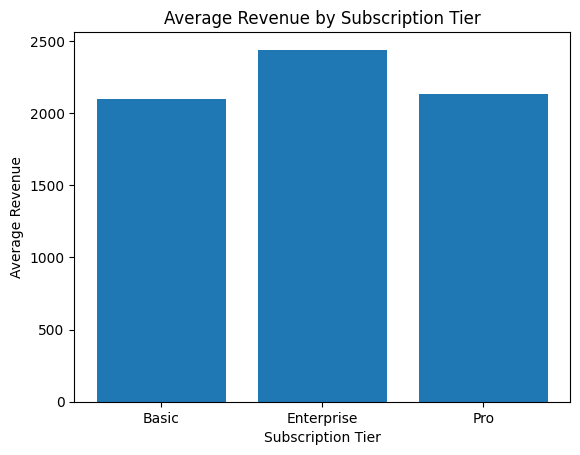

In [44]:
# Revenue Insights: which subscription plan makes the most money?
revenue_by_tier = df.groupby('subscription_tier')['monthly_revenue'].mean()

plt.figure()
plt.bar(revenue_by_tier.index, revenue_by_tier.values)
plt.title("Average Revenue by Subscription Tier")
plt.xlabel("Subscription Tier")
plt.ylabel("Average Revenue")
plt.show()

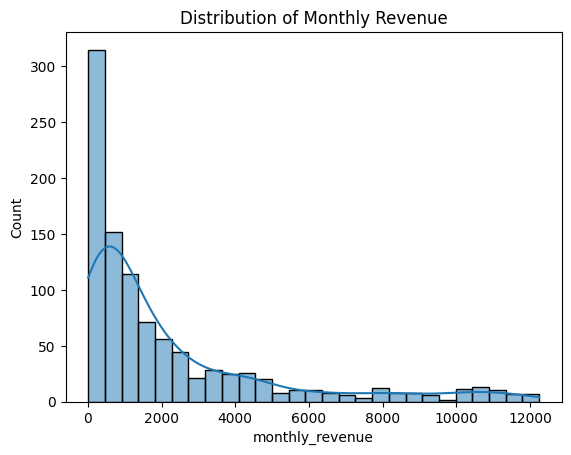

In [31]:
# Revenue Distribution shows skewness; few big customers vs many small ones
sns.histplot(df['monthly_revenue'], kde=True)
plt.title("Distribution of Monthly Revenue")
plt.show()

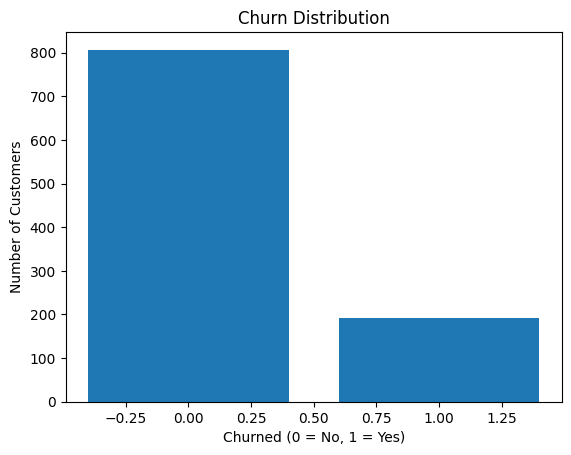

In [32]:
# Churn Distribution
churn_counts = df['churned'].value_counts()

plt.figure()
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

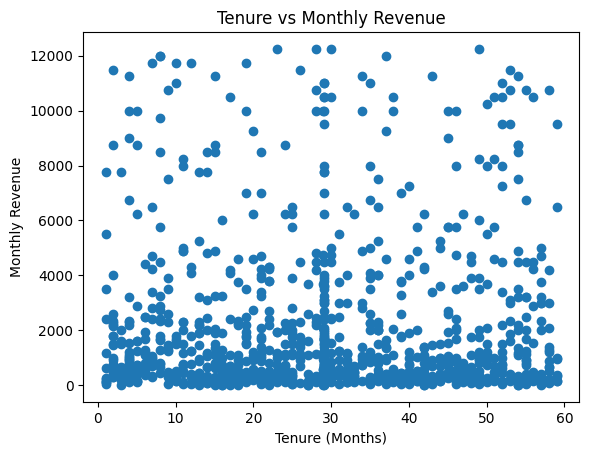

In [33]:
# Scatterplot showing Tenure vs Revenue: Do longer customers pay more?
plt.figure()
plt.scatter(df['tenure_months'], df['monthly_revenue'])
plt.title("Tenure vs Monthly Revenue")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Revenue")
plt.show()

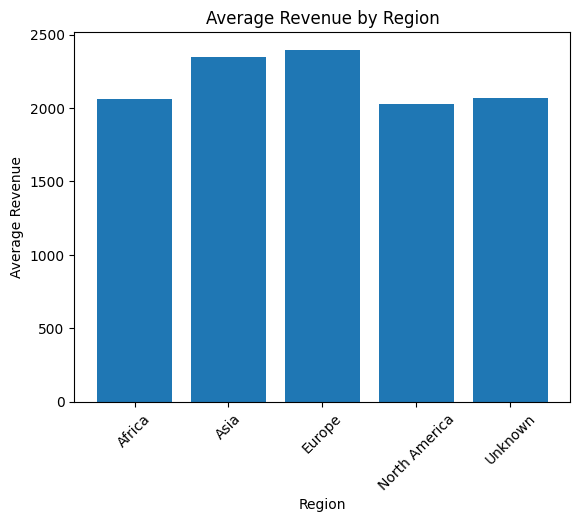

In [34]:
# Revenue by Region: finding the best performing market
region_revenue = df.groupby('region')['monthly_revenue'].mean()

plt.figure()
plt.bar(region_revenue.index, region_revenue.values)
plt.title("Average Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()

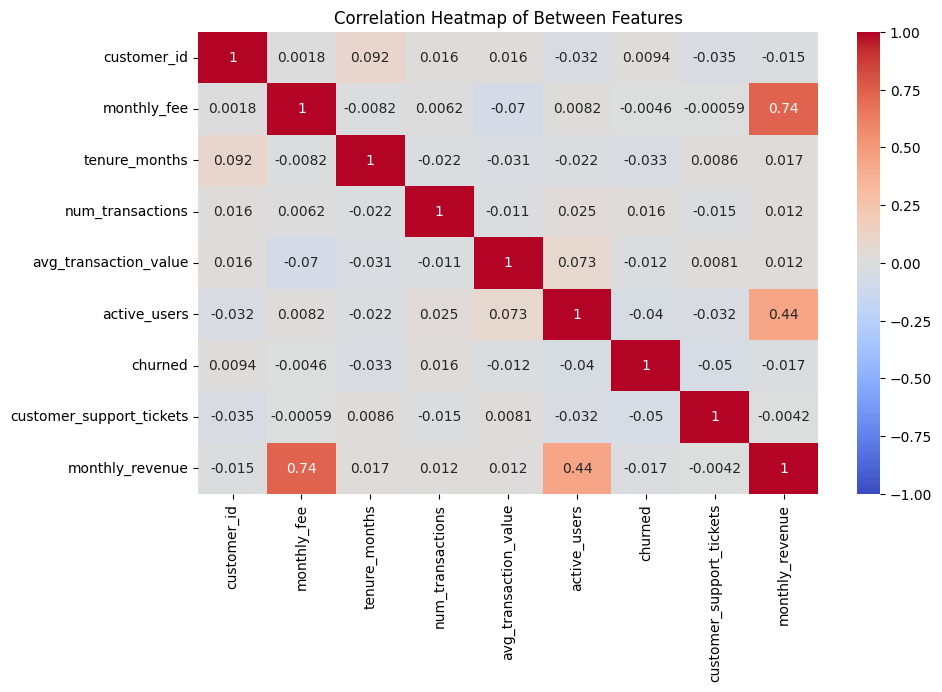

In [51]:
from pandas.core.arrays import numeric
# Correlation heatmap showing key relationship between variables
plt.figure(figsize=(10, 6))
numeric_columns = df.select_dtypes(include=['float64','int64'])
corr_matrix = numeric_columns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',vmin=-1,vmax=1)
plt.title("Correlation Heatmap of Between Features")
plt.show()

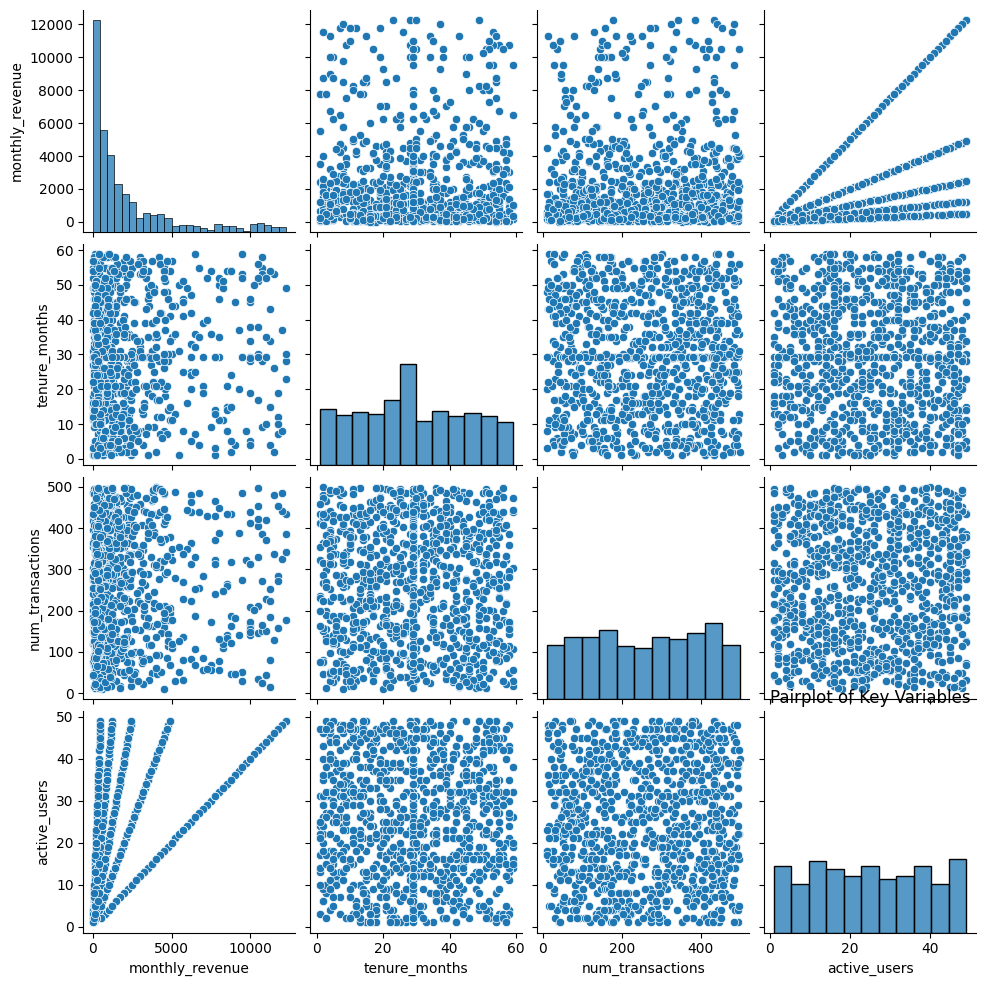

In [42]:
# A pairplot showing the relationship between multiple variables at the same
# time using scatter plots.
sns.pairplot(df[['monthly_revenue','tenure_months','num_transactions','active_users']])
plt.show()

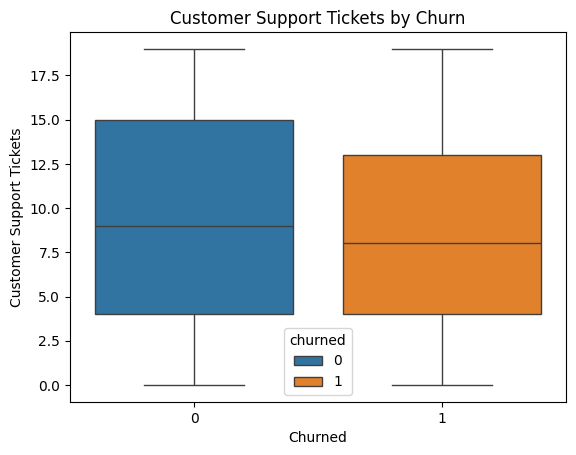

In [38]:
# Boxplot showing the distribution of churn rate based on support tickets
sns.boxplot(x='churned', y='customer_support_tickets', data=df, hue= 'churned')
plt.title("Customer Support Tickets by Churn")
plt.xlabel("Churned")
plt.ylabel("Customer Support Tickets")
plt.show()
